In [16]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from plotly.subplots import make_subplots

# Load dataset
iris = load_iris()
X = iris.data[:, :2]  # Take only sepal length & width (2D for easy plotting)
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different regularization strengths (C is inverse of λ, smaller C = stronger regularization)
C_values = [0.01, 0.1, 1, 100]

results = []
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 200),
                     np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 200))

# Train models with different C values
for C in C_values:
    clf = LogisticRegression(C=C, solver="lbfgs", multi_class="multinomial", max_iter=200)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Predict decision boundary
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    results.append({
        "C": C,
        "accuracy": acc,
        "clf": clf,
        "xx": xx,
        "yy": yy,
        "Z": Z
    })

# Plot decision boundaries with Plotly
fig = make_subplots(rows=1, cols=len(C_values),
                    subplot_titles=[f"C={r['C']} (Acc={r['accuracy']:.2f})" for r in results])

colors = ['red', 'green', 'blue']
for i, res in enumerate(results):
    fig.add_trace(
        go.Contour(
            x=res["xx"][0],
            y=res["yy"][:,0],
            z=res["Z"],
            showscale=False,
            colorscale=[[0, colors[0]], [0.33, colors[0]], [0.34, colors[1]], [0.66, colors[1]], [0.67, colors[2]], [1, colors[2]]],
            opacity=0.3
        ),
        row=1, col=i+1
    )

    fig.add_trace(
        go.Scatter(
            x=X_test[:,0], y=X_test[:,1],
            mode='markers',
            marker=dict(color=y_test, colorscale='Viridis', line=dict(width=1, color="black")),
            name=f"Test Data"
        ),
        row=1, col=i+1
    )

fig.update_layout(title="Logistic Regression with Regularization (Iris Dataset)", height=500, width=1200)
fig.show()


c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 an

In [17]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data[:, :2]  # Take only sepal length & width (2D for easy plotting)
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different regularization strengths (C is inverse of λ)
C_values = np.logspace(-3, 3, 20)  # from 0.001 to 1000

results = []
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 200),
                     np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 200))

accuracies = []

# Train models with different C values
for C in C_values:
    clf = LogisticRegression(C=C, solver="lbfgs", multi_class="multinomial", max_iter=200)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot Accuracy vs C
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(
    x=C_values, y=accuracies, mode="lines+markers",
    name="Test Accuracy"
))
fig_acc.update_xaxes(type="log")  # log scale for C
fig_acc.update_layout(
    title="Accuracy vs Regularization Strength (C)",
    xaxis_title="C (log scale, larger C = weaker regularization)",
    yaxis_title="Accuracy",
    height=500, width=700
)
fig_acc.show()


c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 an

In [18]:
arr = np.linspace(0,50, 100)
print(arr)

[ 0.          0.50505051  1.01010101  1.51515152  2.02020202  2.52525253
  3.03030303  3.53535354  4.04040404  4.54545455  5.05050505  5.55555556
  6.06060606  6.56565657  7.07070707  7.57575758  8.08080808  8.58585859
  9.09090909  9.5959596  10.1010101  10.60606061 11.11111111 11.61616162
 12.12121212 12.62626263 13.13131313 13.63636364 14.14141414 14.64646465
 15.15151515 15.65656566 16.16161616 16.66666667 17.17171717 17.67676768
 18.18181818 18.68686869 19.19191919 19.6969697  20.2020202  20.70707071
 21.21212121 21.71717172 22.22222222 22.72727273 23.23232323 23.73737374
 24.24242424 24.74747475 25.25252525 25.75757576 26.26262626 26.76767677
 27.27272727 27.77777778 28.28282828 28.78787879 29.29292929 29.7979798
 30.3030303  30.80808081 31.31313131 31.81818182 32.32323232 32.82828283
 33.33333333 33.83838384 34.34343434 34.84848485 35.35353535 35.85858586
 36.36363636 36.86868687 37.37373737 37.87878788 38.38383838 38.88888889
 39.39393939 39.8989899  40.4040404  40.90909091 41.

X array:
[[-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]]

Y array:
[[-2. -2. -2. -2. -2.]
 [-1. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.]
 [ 1.  1.  1.  1.  1.]
 [ 2.  2.  2.  2.  2.]]


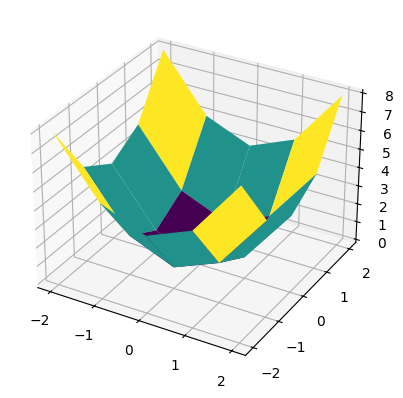

In [19]:
import numpy as np

# Create 1D coordinate vectors using linspace
x = np.linspace(-2, 2, 5)  # [-2. -1.  0.  1.  2.]
y = np.linspace(-2, 2, 5)  # [-2. -1.  0.  1.  2.]

# Use meshgrid to create 2D coordinate matrices
X, Y = np.meshgrid(x, y)

print("X array:")
print(X)
print("\nY array:")
print(Y)

import matplotlib.pyplot as plt

# The 2D arrays X and Y are already defined from the previous example
Z = X**2 + Y**2  # Calculate Z-values for each (X, Y) pair

# Plotting the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, cmap=plt.cm.viridis)
plt.show()


In [20]:
import numpy as np
import plotly.graph_objects as go

# Regularization strength (λ) from weak to strong
lambdas = np.linspace(0.01, 10, 100)

# Simulated bias² and variance curves
bias2 = np.log1p(lambdas) / 3        # grows with λ
variance = 1 / (1 + lambdas)         # decreases with λ
noise = 0.1                          # irreducible noise

# Total error
total_error = bias2 + variance + noise

# Plot with Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=lambdas, y=bias2, mode='lines', name='Bias²', line=dict(color='red')))
fig.add_trace(go.Scatter(x=lambdas, y=variance, mode='lines', name='Variance', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=lambdas, y=total_error, mode='lines', name='Total Error', line=dict(color='green')))
fig.add_trace(go.Scatter(x=lambdas, y=[noise]*len(lambdas), mode='lines', name='Noise', line=dict(color='gray', dash='dot')))

fig.update_layout(
    title="Bias–Variance Tradeoff and Regularization Effect",
    xaxis_title="Regularization Strength (λ)",
    yaxis_title="Error",
    width=800,
    height=500
)

fig.show()


In [21]:
import plotly.express as px 
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [23]:
iris = load_iris()
x,y = iris.data , iris.target

# train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


# standardize the feature (important for neural networks)
std = StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

# different regularization strength 
alphas = np.logspace(-5, 2 , 20)
accuracies = []

for alpha in alphas :
    clf = MLPClassifier(
        hidden_layer_sizes=(50,30),
        max_iter=2000,
        random_state=42,
        alpha = alpha
    )

    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    acc = accuracy_score(y_test,y_pred)
    accuracies.append(acc)


# Plot Accuracy vs Regularization strength
fig = px.line(x=alphas, y=accuracies, markers=True,
              title="Effect of Regularization (L2) on Neural Network - Iris Dataset",
              labels={"x": "Regularization Strength (alpha, log scale)", "y": "Test Accuracy"})
fig.update_xaxes(type="log")
fig.show()

In [ ]:
import numpy as np
import plotly.express as px
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for neural nets)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different regularization strengths
alphas = np.logspace(-5, 2, 20)
accuracies = []

for alpha in alphas:
    clf = MLPClassifier(
        hidden_layer_sizes=(50, 30),
        max_iter=2000,
        random_state=42,
        alpha=alpha  # L2 regularization strength
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot Accuracy vs Regularization strength
fig = px.line(
    x=alphas,
    y=accuracies,
    markers=True,
    title="Effect of Regularization (L2) on Neural Network - Iris Dataset",
    labels={"x": "Regularization Strength (alpha, log scale)", "y": "Test Accuracy"}
)
fig.update_xaxes(type="log")
fig.show()


In [26]:
# bayes_opt_mlp_iris.py  (copy+run)
import json, joblib, os, time
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

# ---- setup output dir for checkpointing/logging ----
OUT_DIR = "bo_runs"
os.makedirs(OUT_DIR, exist_ok=True)
TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
RUN_FILE = os.path.join(OUT_DIR, f"bo_run_{TIMESTAMP}.pkl")

# ---- load data ----
iris = load_iris()
X, y = iris.data, iris.target

# ---- search space (example: tuning architecture + optimizer hyperparams) ----
space = [
    Integer(10, 200, name="hidden_layer_1"),             # first hidden layer size
    Integer(0, 100, name="hidden_layer_2"),              # second hidden (0 => no second layer)
    Real(1e-5, 1e-1, "log-uniform", name="learning_rate_init"),
    Real(1e-6, 1e-1, "log-uniform", name="alpha"),      # L2 penalty (weight decay)
    Categorical(['relu', 'tanh'], name="activation"),
]

# ---- objective: negative CV accuracy (we minimize) ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

@use_named_args(space)
def objective(**params):
    # decode params
    h1 = int(params["hidden_layer_1"])
    h2 = int(params["hidden_layer_2"])
    if h2 == 0:
        hidden = (h1,)
    else:
        hidden = (h1, h2)
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=params["activation"],
            learning_rate_init=params["learning_rate_init"],
            alpha=params["alpha"],
            max_iter=2000,
            random_state=42,
        ))
    ])
    # use CV score (accuracy)
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy", n_jobs=1)
    acc = np.mean(scores)
    # skopt minimizes; we want to maximize accuracy -> minimize negative accuracy
    result = -acc

    # checkpoint partial result (append)
    record = {"params": params, "cv_mean_accuracy": acc}
    with open(RUN_FILE, "ab") as f:
        joblib.dump(record, f)   # appendable binary pickles

    return result

# ---- run Bayesian Optimization ----
N_CALLS = 40
res = gp_minimize(
    objective,
    space,
    acq_func="EI",        # Expected Improvement
    n_calls=N_CALLS,
    n_random_starts=8,
    random_state=42,
    verbose=True,
)

# save full result
joblib.dump(res, RUN_FILE.replace(".pkl", "_final.pkl"))

# ---- inspect best result ----
best_idx = res.x_iters.index(res.x)
best_params = dict(zip([s.name for s in space], res.x))
best_score = -res.fun
print("BEST: score=%.4f params=%s" % (best_score, best_params))

# ---- Plot convergence with Plotly (interactive) ----
# prepare data
iters = np.arange(1, len(res.func_vals)+1)
best_so_far = np.minimum.accumulate(res.func_vals) * -1  # convert to accuracy (maximize)
raw_acc = -np.array(res.func_vals)  # each eval accuracy

fig = go.Figure()
fig.add_trace(go.Scatter(x=iters, y=raw_acc, mode="markers+lines", name="Eval accuracy"))
fig.add_trace(go.Scatter(x=iters, y=best_so_far, mode="lines", name="Best so far"))
fig.update_layout(
    title="BO Optimization Trace (accuracy per eval)",
    xaxis_title="Iteration",
    yaxis_title="Accuracy",
    width=900, height=450
)
fig.show()

# ---- Parameter importance table (simple) ----
# build DataFrame of evaluated params
rows = []
for params, acc in zip(res.x_iters, -res.func_vals):
    rows.append({name: val for name, val in zip([s.name for s in space], params)} | {"accuracy": acc})
df = pd.DataFrame(rows)
display_df = df.sort_values("accuracy", ascending=False).reset_index(drop=True)
print(display_df.head(10))

# Save results dataframe
display_df.to_csv(os.path.join(OUT_DIR, f"bo_results_{TIMESTAMP}.csv"), index=False)


Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.4039
Function value obtained: -0.9467
Current minimum: -0.9467
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 2.9664
Function value obtained: -0.9533
Current minimum: -0.9533
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.4783
Function value obtained: -0.9333
Current minimum: -0.9533
Iteration No: 4 started. Evaluating function at random point.


c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perce

Iteration No: 4 ended. Evaluation done at random point.
Time taken: 15.0397
Function value obtained: -0.8867
Current minimum: -0.9533
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.1730
Function value obtained: -0.9267
Current minimum: -0.9533
Iteration No: 6 started. Evaluating function at random point.
Iteration No: 6 ended. Evaluation done at random point.
Time taken: 0.5840
Function value obtained: -0.9533
Current minimum: -0.9533
Iteration No: 7 started. Evaluating function at random point.


c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perce

Iteration No: 7 ended. Evaluation done at random point.
Time taken: 14.8949
Function value obtained: -0.9267
Current minimum: -0.9533
Iteration No: 8 started. Evaluating function at random point.


...

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perce

Iteration No: 17 ended. Search finished for the next optimal point.
Time taken: 2.7226
Function value obtained: -0.8267
Current minimum: -0.9667
Iteration No: 18 started. Searching for the next optimal point.
Iteration No: 18 ended. Search finished for the next optimal point.
Time taken: 0.6557
Function value obtained: -0.9467
Current minimum: -0.9667
Iteration No: 19 started. Searching for the next optimal point.
Iteration No: 19 ended. Search finished for the next optimal point.
Time taken: 1.0705
Function value obtained: -0.9600
Current minimum: -0.9667
Iteration No: 20 started. Searching for the next optimal point.
Iteration No: 20 ended. Search finished for the next optimal point.
Time taken: 1.5640
Function value obtained: -0.9400
Current minimum: -0.9667
Iteration No: 21 started. Searching for the next optimal point.
Iteration No: 21 ended. Search finished for the next optimal point.
Time taken: 0.6736
Function value obtained: -0.8333
Current minimum: -0.9667
Iteration No: 22 st

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.

c:\Users\Asus\.conda\envs\gpuvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perce

Iteration No: 32 ended. Search finished for the next optimal point.
Time taken: 3.2414
Function value obtained: -0.8533
Current minimum: -0.9733
Iteration No: 33 started. Searching for the next optimal point.
Iteration No: 33 ended. Search finished for the next optimal point.
Time taken: 0.5078
Function value obtained: -0.9600
Current minimum: -0.9733
Iteration No: 34 started. Searching for the next optimal point.
Iteration No: 34 ended. Search finished for the next optimal point.
Time taken: 0.3870
Function value obtained: -0.9400
Current minimum: -0.9733
Iteration No: 35 started. Searching for the next optimal point.
Iteration No: 35 ended. Search finished for the next optimal point.
Time taken: 3.3447
Function value obtained: -0.9733
Current minimum: -0.9733
Iteration No: 36 started. Searching for the next optimal point.
Iteration No: 36 ended. Search finished for the next optimal point.
Time taken: 0.9395
Function value obtained: -0.9467
Current minimum: -0.9733
Iteration No: 37 st

   hidden_layer_1  hidden_layer_2  learning_rate_init     alpha activation  \
0             200               0            0.001747  0.040615       tanh   
1             105             100            0.000427  0.000003       tanh   
2             200               0            0.004331  0.016076       tanh   
3             129               0            0.000945  0.100000       tanh   
4              20               0            0.006835  0.016460       tanh   
5              41              73            0.000387  0.000003       tanh   
6             142               0            0.003760  0.000003       relu   
7              10             100            0.000676  0.000643       tanh   
8             151               0            0.000436  0.063835       relu   
9              10               0            0.000925  0.000001       tanh   

   accuracy  
0  0.973333  
1  0.973333  
2  0.973333  
3  0.973333  
4  0.966667  
5  0.966667  
6  0.960000  
7  0.960000  
8  0.960000  
9